In [1]:
!unzip /content/Bones-data.zip

Archive:  /content/Bones-data.zip
   creating: Bones-data/
   creating: Bones-data/test/
   creating: Bones-data/test/Oblique fracture/
  inflating: Bones-data/test/Oblique fracture/0-_gallery_jpeg.rf.b3170266ea6b6d03bfb4ae5991df98ce.jpg  
  inflating: Bones-data/test/Oblique fracture/10-1055-b-002-85516_c023_f003-1_jpg.rf.a2cb46deb0263fc9290f45ee328c632.jpg  
  inflating: Bones-data/test/Oblique fracture/10-1055-b-002-85516_c023_f003-1_jpg.rf.a2cb46deb0263fc92980f45ee328c632.jpg  
  inflating: Bones-data/test/Oblique fracture/1000_F_264769365_u927dRxrrx1fi4rlR1VWif9LcGeJwv4h_jpg.rf.b2d149cb90da63cbc49ec73e82bf0935.jpg  
  inflating: Bones-data/test/Oblique fracture/119913828-radiography-with-oblique-fibula-fracture_jpg.rf.8f0f4e48c3c959ca7b930e3cba8fafd0.jpg  
  inflating: Bones-data/test/Oblique fracture/220px-MalletFinger-PNG_jpg.rf.8eb8b19e344b2ab4d48b4cbeda7b4a80.jpg  
  inflating: Bones-data/test/Oblique fracture/2624240dc461d0c5d2d7fb7e16b3065c_jpg.rf.628b0bc8b7bb91626b4835d7b36

In [2]:
# re-size all the images to this
IMAGE_SIZE = [224, 224]

In [3]:
size = [224, 224] + [3]
size

[224, 224, 3]

In [4]:
train_path = "/content/Bones-data/train"
valid_path = "/content/Bones-data/test"

In [5]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
import numpy as np
from glob import glob
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten

In [6]:
vgg16 = VGG16(input_shape=IMAGE_SIZE + [3],  weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
for layer in vgg16.layers:
  print(layer.trainable)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [8]:
for layer in vgg16.layers:
    layer.trainable = False

In [9]:
for layer in vgg16.layers:
  print(layer.name,layer.trainable)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [10]:
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
folders = glob('/content/Bones-data/train/*')
folders

['/content/Bones-data/train/Oblique fracture',
 '/content/Bones-data/train/Spiral Fracture']

In [13]:
num_of_class = len(folders)
num_of_class

2

In [14]:
model = Sequential()
model.add(vgg16)

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(num_of_class,activation='softmax'))

In [15]:
# view the structure of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 6,423,298 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [19]:
training_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 143 images belonging to 2 classes.


In [20]:
test_set = test_datagen.flow_from_directory(valid_path,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 28 images belonging to 2 classes.


In [21]:
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=10,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 6s/step - accuracy: 0.5035 - loss: 3.9333 - val_accuracy: 0.4643 - val_loss: 2.5184
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 0.6713 - loss: 1.1053 - val_accuracy: 0.6786 - val_loss: 0.8657
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 409ms/step - accuracy: 0.7133 - loss: 0.6109 - val_accuracy: 0.5357 - val_loss: 1.0189
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.7902 - loss: 0.4281 - val_accuracy: 0.5714 - val_loss: 0.8524
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 0.8112 - loss: 0.4462 - val_accuracy: 0.5714 - val_loss: 0.8256
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 0.8881 - loss: 0.2912 - val_accuracy: 0.6071 - val_loss: 0.8782
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 508ms/step - accuracy: 0.8462 - loss: 0.4165 - val_accuracy: 0.5000 - val_loss: 1.1600
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - accuracy: 0.8601 - loss: 0.3090 - val_accuracy: 0.6071 - val_loss: 0

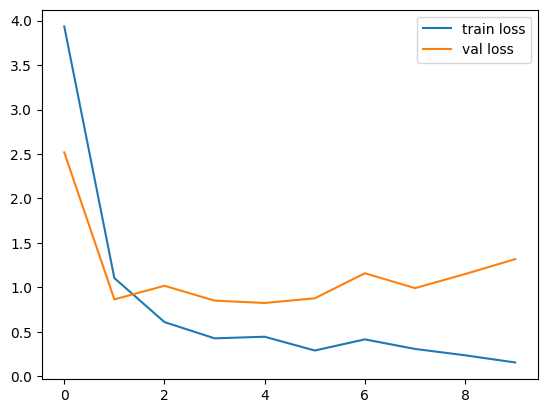

<Figure size 640x480 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

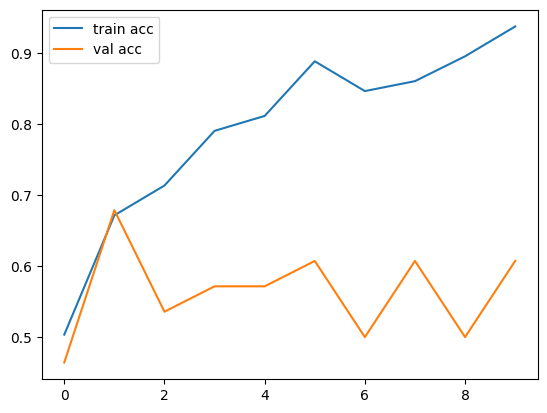

<Figure size 640x480 with 0 Axes>

In [23]:
# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig("AccVal_acc")

In [24]:
model.evaluate(test_set)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6071 - loss: 1.3183


[1.3183029890060425, 0.6071428656578064]

In [25]:
from tensorflow.keras.models import load_model

model.save('model_vgg16.h5')

In [26]:
model = load_model("model_vgg16.h5")

In [27]:
from tensorflow.keras.preprocessing import image

In [28]:
img = "/content/Bones-data/test/Oblique fracture/220px-MalletFinger-PNG_jpg.rf.8eb8b19e344b2ab4d48b4cbeda7b4a80.jpg"

In [29]:
img=image.load_img(img,target_size=(224,224))

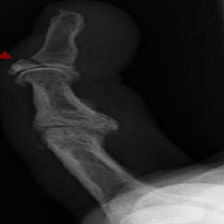

In [30]:
img

In [31]:
x=image.img_to_array(img)
x

array([[[  8.,   8.,   8.],
        [  8.,   8.,   8.],
        [  8.,   8.,   8.],
        ...,
        [ 29.,  29.,  29.],
        [ 34.,  34.,  34.],
        [ 45.,  45.,  45.]],

       [[  8.,   8.,   8.],
        [  8.,   8.,   8.],
        [  8.,   8.,   8.],
        ...,
        [ 27.,  27.,  27.],
        [ 33.,  33.,  33.],
        [ 43.,  43.,  43.]],

       [[  8.,   8.,   8.],
        [  8.,   8.,   8.],
        [  8.,   8.,   8.],
        ...,
        [ 26.,  26.,  26.],
        [ 32.,  32.,  32.],
        [ 42.,  42.,  42.]],

       ...,

       [[  6.,   6.,   6.],
        [  6.,   6.,   6.],
        [  6.,   6.,   6.],
        ...,
        [228., 228., 228.],
        [232., 232., 232.],
        [232., 232., 232.]],

       [[  6.,   6.,   6.],
        [  6.,   6.,   6.],
        [  6.,   6.,   6.],
        ...,
        [226., 226., 226.],
        [230., 230., 230.],
        [230., 230., 230.]],

       [[  6.,   6.,   6.],
        [  6.,   6.,   6.],
        [  6.,  

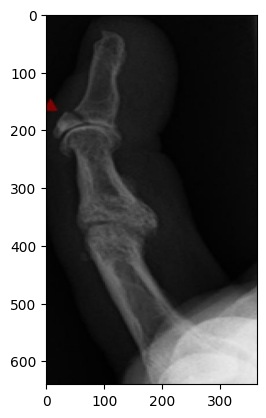

In [32]:
Z = plt.imread('/content/Bones-data/test/Oblique fracture/220px-MalletFinger-PNG_jpg.rf.8eb8b19e344b2ab4d48b4cbeda7b4a80.jpg')
plt.imshow(Z)

In [33]:
x.shape

(224, 224, 3)

In [34]:
x=x/255

In [35]:
from keras.applications.vgg16 import preprocess_input
import numpy as np
x=np.expand_dims(x,axis=0)
img_data=preprocess_input(x)

In [36]:
img_data

array([[[[-103.90763 , -116.74763 , -123.64863 ],
         [-103.90763 , -116.74763 , -123.64863 ],
         [-103.90763 , -116.74763 , -123.64863 ],
         ...,
         [-103.82528 , -116.665276, -123.56628 ],
         [-103.80567 , -116.64567 , -123.54667 ],
         [-103.762535, -116.60253 , -123.50353 ]],

        [[-103.90763 , -116.74763 , -123.64863 ],
         [-103.90763 , -116.74763 , -123.64863 ],
         [-103.90763 , -116.74763 , -123.64863 ],
         ...,
         [-103.83312 , -116.67312 , -123.57412 ],
         [-103.80959 , -116.64959 , -123.55059 ],
         [-103.77038 , -116.610374, -123.511375]],

        [[-103.90763 , -116.74763 , -123.64863 ],
         [-103.90763 , -116.74763 , -123.64863 ],
         [-103.90763 , -116.74763 , -123.64863 ],
         ...,
         [-103.83704 , -116.67704 , -123.57804 ],
         [-103.813515, -116.65351 , -123.55451 ],
         [-103.7743  , -116.614296, -123.5153  ]],

        ...,

        [[-103.915474, -116.75547 , -1

In [37]:
output = model.predict(img_data)
output

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([[0.00190518, 0.99809486]], dtype=float32)

In [38]:
result = np.argmax(output, axis=1)
result

array([1])

In [39]:
if result[0] == 0:
    prediction = 'Oblique fracture'
    print(prediction)
else:
    prediction = 'Spiral Fracture'
    print(prediction)

Spiral Fracture
